In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd


data=pd.read_excel('/content/advertising_sales_data.xlsx')
print(data)



    Campaign     TV  Radio  Newspaper  Sales
0      camp1  230.1   37.8       69.2   22.1
1      camp2   44.5   39.3       45.1   10.4
2      camp3   17.2   45.9       69.3   12.0
3      camp4  151.5   41.3       58.5   16.5
4      camp5  180.8   10.8       58.4   17.9
..       ...    ...    ...        ...    ...
195  camp196   38.2    3.7       13.8    7.6
196  camp197   94.2    4.9        8.1   14.0
197  camp198  177.0    9.3        6.4   14.8
198  camp199  283.6   42.0       66.2   25.5
199  camp200  232.1    8.6        8.7   18.4

[200 rows x 5 columns]


In [8]:
import pandas as pd

data = pd.read_excel('/content/advertising_sales_data.xlsx')

# Calculate the average TV spend
avg_tv = data['TV'].mean()
print("Average TV advertising spend:", avg_tv)

Average TV advertising spend: 147.0425


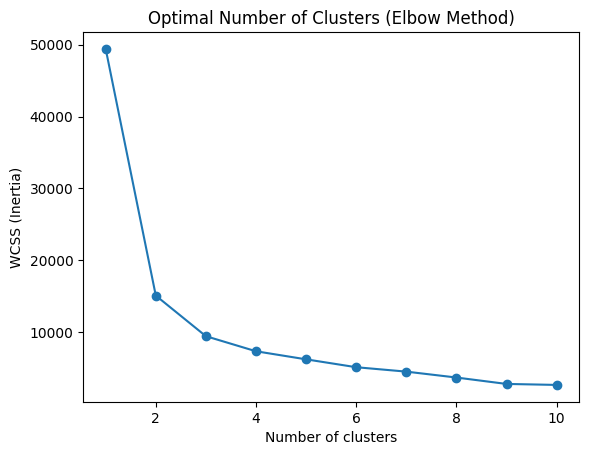

In [16]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


data=pd.read_excel('/content/advertising_sales_data.xlsx')
X=data['Radio']
y=data['Sales']

X_train,X_test,y_test,y_train=train_test_split(X,y,random_state=80,test_size=0.2)

model=LinearRegression()

X_train

In [17]:
corr_radio_sales = data['Radio'].corr(data['Sales'])
print("Correlation between Radio and Sales:", corr_radio_sales)

Correlation between Radio and Sales: 0.3497277129207837


In [18]:
corrs = data[['TV','Radio','Newspaper','Sales']].corr()
print(corrs['Sales'])

TV           0.901372
Radio        0.349728
Newspaper    0.159125
Sales        1.000000
Name: Sales, dtype: float64


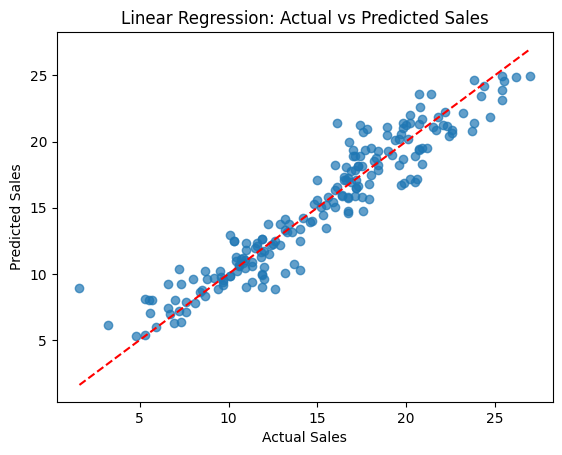

In [19]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Features and target
X = data[['TV','Radio','Newspaper']]
y = data['Sales']

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Visualization
plt.scatter(y, y_pred, alpha=0.7)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Linear Regression: Actual vs Predicted Sales")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 45-degree line
plt.show()

In [20]:
new_data = pd.DataFrame({'TV':[200], 'Radio':[40], 'Newspaper':[50]})
predicted_sales = model.predict(new_data)
print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 19.819378160410906


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

X = data[['TV','Radio','Newspaper']]
y = data['Sales']

# Model without normalization
model_raw = LinearRegression()
model_raw.fit(X, y)
y_pred_raw = model_raw.predict(X)

# Model with normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y)
y_pred_scaled = model_scaled.predict(X_scaled)

# Compare performance
print("Raw R²:", r2_score(y, y_pred_raw))
print("Scaled R²:", r2_score(y, y_pred_scaled))
print("Raw Coefficients:", model_raw.coef_)
print("Scaled Coefficients:", model_scaled.coef_)

Raw R²: 0.9029164691118196
Scaled R²: 0.9029164691118196
Raw Coefficients: [ 5.44940753e-02  1.07180244e-01 -1.90190181e-05]
Scaled Coefficients: [ 4.68623742e+00  1.59529055e+00 -4.14366193e-04]


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X_subset = data[['Radio','Newspaper']]
y = data['Sales']

model_subset = LinearRegression()
model_subset.fit(X_subset, y)

y_pred_subset = model_subset.predict(X_subset)

print("R² (Radio + Newspaper):", r2_score(y, y_pred_subset))
print("MSE (Radio + Newspaper):", mean_squared_error(y, y_pred_subset))
print("Coefficients:", model_subset.coef_)

R² (Radio + Newspaper): 0.12370915572237262
MSE (Radio + Newspaper): 24.57835889084603
Coefficients: [0.11938444 0.0097279 ]


In [23]:
X_full = data[['TV','Radio','Newspaper']]
model_full = LinearRegression()
model_full.fit(X_full, y)
y_pred_full = model_full.predict(X_full)

print("R² (Full model):", r2_score(y, y_pred_full))
print("MSE (Full model):", mean_squared_error(y, y_pred_full))

R² (Full model): 0.9029164691118196
MSE (Full model): 2.7230158572833956
